BASELINES

In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from datetime import datetime
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

LOAD & BUILD df 

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

base_path = '/Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced AI/BUSit week/Attendance AI/Project 2 - Matchday Attendance Prediction/Data/'
# ── Load ──────────────────────────────────────────────────────────────
df_match   = pd.read_csv(base_path + 'gold_match.csv')
df_tickets = pd.read_csv(base_path + 'gold_match_tickets.csv')
df_context = pd.read_csv(base_path + 'gold_match_context.csv')
df_trends  = pd.read_csv(base_path + 'gold_google_trends_daily.csv')

# ── Merge ─────────────────────────────────────────────────────────────
# ── Merge ─────────────────────────────────────────────────────────────
df = df_match[df_match['is_home_match'] == True].copy()
df = df.merge(df_context, on='match_id', how='left', suffixes=('', '_ctx'))
df = df.merge(
    df_tickets[['match_id', 'tickets_sold_total', 'tickets_sold_b2c',
                'tickets_sold_b2b', 'seasonpass_holders']],
    on='match_id', how='left'
)

# promo_tickets_total and pct_free_tickets already came in from df_context ✅

# ── Target ────────────────────────────────────────────────────────────
df['target'] = df['tickets_sold_total'].fillna(df['tickets_scanned'])

# ── Google Trends buzz ────────────────────────────────────────────────
df_trends['date'] = pd.to_datetime(df_trends['date'])
df['match_date']  = pd.to_datetime(df['match_date'])

buzz = []
for _, row in df[['match_id', 'match_date']].iterrows():
    window = df_trends[
        (df_trends['date'] >= row['match_date'] - pd.Timedelta(days=7)) &
        (df_trends['date'] <  row['match_date'])
    ]['ohl_interest'].mean()
    buzz.append({'match_id': row['match_id'], 'google_buzz_7d': window})

df = df.merge(pd.DataFrame(buzz), on='match_id', how='left')

# ── Timing features ───────────────────────────────────────────────────
df['kickoff_time_local'] = pd.to_datetime(df['kickoff_time_local'], format='%H:%M:%S', errors='coerce')
df['kickoff_hour'] = df['kickoff_time_local'].dt.hour

def time_of_day(hour):
    if pd.isna(hour):   return 'unknown'
    if hour < 13:       return 'morning'
    elif hour < 17:     return 'afternoon'
    elif hour < 20:     return 'early_evening'
    else:               return 'night'

df['time_of_day'] = df['kickoff_hour'].apply(time_of_day)
df = pd.get_dummies(df, columns=['time_of_day', 'weekday_name'], drop_first=False)

for col in ['is_weekend', 'is_midweek', 'is_public_holiday',
            'is_school_holiday_flanders', 'has_promotion']:
    if col in df.columns:
        df[col] = df[col].astype(int)

print("✅ df ready")
print(f"  Rows:          {len(df)}")
print(f"  target non-null: {df['target'].notna().sum()}")
print(f"  Columns:       {len(df.columns)}")

✅ df ready
  Rows:          71
  target non-null: 71
  Columns:       75


In [16]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL A — BASELINES                                                 ║
# ╚══════════════════════════════════════════════════════════════════════╝
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

df_home = df[df['target'].notna()].copy()
df_home = df_home.sort_values('match_date')

# ── Season card no-show analysis ──────────────────────────────────────
df_home['seasoncard_scanners'] = (
    df_home['tickets_sold_total'] - df_home['tickets_sold_b2c'] - df_home['tickets_sold_b2b']
)
df_home['seasoncard_noshow']    = df_home['seasonpass_holders'] - df_home['seasoncard_scanners']
df_home['seasoncard_noshow_pct'] = df_home['seasoncard_noshow'] / df_home['seasonpass_holders']
df_home['seasoncard_showrate']   = df_home['seasoncard_scanners'] / df_home['seasonpass_holders']

# ── 1. Season average ─────────────────────────────────────────────────
season_avg          = df_home.groupby('season')['target'].transform('mean')
baseline_season_mae = mean_absolute_error(df_home['target'], season_avg)
baseline_season_r2  = r2_score(df_home['target'], season_avg)

# ── 2. Same fixture last year ─────────────────────────────────────────
df_home['fixture_key'] = df_home['away_team']
fixture_last_year      = df_home.groupby('fixture_key')['target'].shift(1)
mask                   = fixture_last_year.notna()
baseline_fixture_mae   = mean_absolute_error(df_home.loc[mask, 'target'], fixture_last_year[mask])
baseline_fixture_r2    = r2_score(df_home.loc[mask, 'target'], fixture_last_year[mask])

# ── 3. Opponent category average ──────────────────────────────────────
top6    = ['Club Brugge', 'Anderlecht', 'KV Mechelen', 'STVV', 'Westerlo', 'Gent']
bottom6 = ['Beerschot', 'Lommel', 'OH Leuven', 'Dender', 'Kortrijk', 'Rwdm']

def opponent_category(team):
    if team in top6:    return 'top'
    if team in bottom6: return 'bottom'
    return 'mid'

df_home['opp_category'] = df_home['away_team'].apply(opponent_category)
cat_avg          = df_home.groupby('opp_category')['target'].transform('mean')
baseline_cat_mae = mean_absolute_error(df_home['target'], cat_avg)
baseline_cat_r2  = r2_score(df_home['target'], cat_avg)

print("=" * 50)
print("  BASELINES")
print("=" * 50)
print(f"  Season average:        MAE={baseline_season_mae:.0f}  R²={baseline_season_r2:.4f}")
print(f"  Same fixture last yr:  MAE={baseline_fixture_mae:.0f}  R²={baseline_fixture_r2:.4f}")
print(f"  Opponent category:     MAE={baseline_cat_mae:.0f}  R²={baseline_cat_r2:.4f}")
print()
print("  ── Our Ridge model ──")
print(f"  Train MAE: 635   Train R²: 0.4258")
print(f"  Test  MAE: 806   Test  R²: 0.2897")
print(f"  CV    MAE: 787   CV    R²: 0.1180")
print("=" * 50)
print()

# ── Season card show-up rate by opponent ──────────────────────────────
print("  Season card show-up rate by opponent:")
showrate = (df_home.groupby('away_team')['seasoncard_showrate']
            .mean()
            .sort_values(ascending=False)
            .round(3))
for team, rate in showrate.items():
    bar = '█' * int(rate * 20)
    print(f"  {team:<25} {rate:.1%}  {bar}")

  BASELINES
  Season average:        MAE=653  R²=0.3920
  Same fixture last yr:  MAE=1277  R²=-2.0352
  Opponent category:     MAE=891  R²=0.0699

  ── Our Ridge model ──
  Train MAE: 635   Train R²: 0.4258
  Test  MAE: 806   Test  R²: 0.2897
  CV    MAE: 787   CV    R²: 0.1180

  Season card show-up rate by opponent:
  Eupen                     93.4%  ██████████████████
  KV Oostende               93.3%  ██████████████████
  RWDM                      91.1%  ██████████████████
  Antwerp                   90.3%  ██████████████████
  Kortrijk                  89.6%  █████████████████
  Standard Liège            89.3%  █████████████████
  Seraing                   88.8%  █████████████████
  Cercle Brugge             88.6%  █████████████████
  Beerschot                 88.5%  █████████████████
  Westerlo                  88.2%  █████████████████
  Genk                      88.0%  █████████████████
  Gent                      88.0%  █████████████████
  Sporting Charleroi        87.2%  █████

CORRELATION HEATMAP    

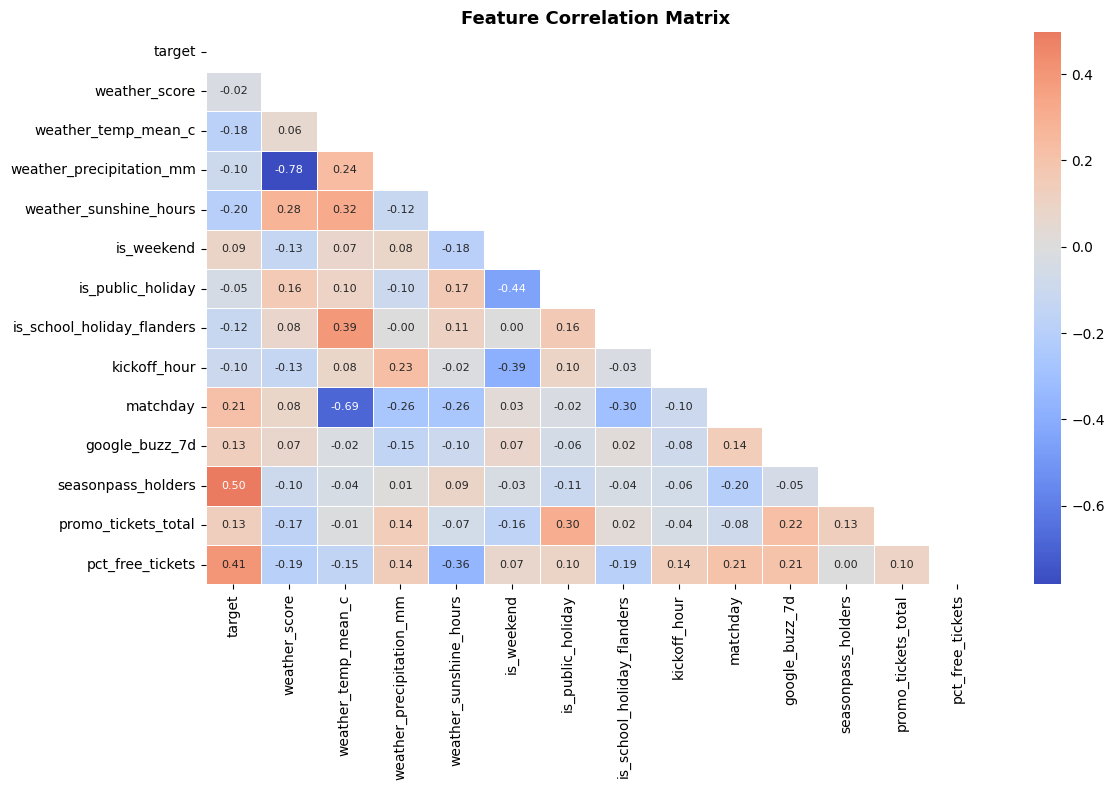

✅ Saved → eda_correlation.png


In [13]:



fig, ax = plt.subplots(figsize=(12, 8))

corr_features = [
    'target',
    'weather_score', 'weather_temp_mean_c',
    'weather_precipitation_mm', 'weather_sunshine_hours',
    'is_weekend', 'is_public_holiday', 'is_school_holiday_flanders',
    'kickoff_hour', 'matchday', 'google_buzz_7d',
    'seasonpass_holders', 'promo_tickets_total', 'pct_free_tickets',
]
corr_features = [c for c in corr_features if c in df_home.columns]

corr = df_home[corr_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → eda_correlation.png")